# Gemma 4 Multimodal Inference Example

This notebook demonstrates how to use the converted Gemma 4 model (`gemma4_instruct_2b`) for multimodal inference, including text, audio, image, and video inputs.


In [1]:
import os
os.environ["KERAS_BACKEND"] = "jax"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import keras
keras.config.set_floatx("bfloat16")

import keras_hub
import numpy as np
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
from scipy.io import wavfile
import av

print("Keras version:", keras.__version__)
print("KerasHub version:", keras_hub.__version__)


2026-04-08 06:57:25.829647: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-08 06:57:25.884544: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Keras version: 3.13.2
KerasHub version: 0.27.0.dev0


In [2]:
# Load the converted model
# Note: Make sure the conversion script has finished running and created the directory.
model_path = "./gemma4_instruct_2b"

if os.path.exists(model_path):
    print(f"Loading model from {model_path}...")
    model = keras_hub.models.Gemma4CausalLM.from_preset(model_path)
    print("Model loaded successfully!")
else:
    print(f"Model path {model_path} does not exist. Please run the conversion script first.")


Loading model from ./gemma4_instruct_2b...


2026-04-08 06:57:30.456404: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


2026-04-08 06:57:36.674801: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 9395240960 exceeds 10% of free system memory.


2026-04-08 06:57:37.056252: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 9395240960 exceeds 10% of free system memory.


2026-04-08 06:57:37.408435: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 9395240960 exceeds 10% of free system memory.


DEBUG: per_layer_token_embedding tracked: True


normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.


2026-04-08 06:57:47.203115: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 9395240960 exceeds 10% of free system memory.


Model loaded successfully!


## 1. Text-only Inference


In [3]:
prompt = "<start_of_turn>user\nExplain the difference between a fruit and a vegetable.<end_of_turn>\n<start_of_turn>model\n"
response = model.generate(prompt, max_length=200)
print(response)


2026-04-08 06:58:13.088382: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fdf84039250 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-04-08 06:58:13.088410: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1775631493.112471  469081 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


<start_of_turn>user
Explain the difference between a fruit and a vegetable.<end_of_turn>
<start_of_turn>model
A fruit and a vegetable are terms used in botany and cooking, and the distinction between them is often more about **culinary use and botanical classification** than a strict scientific rule.

Here is a breakdown of the traditional definitions and the modern, more accurate perspective:

### 1. Botanical Definition (The Scientific View)

From a strict botanical standpoint, the difference is based on **botany**:

*   **Fruit:** A fruit is the mature, ripened ovary of a flowering plant, which contains the seeds. Examples include apples, oranges, tomatoes, and cucumbers.
*   **Vegetable:** A vegetable is generally any edible part of a plant, including roots, stems, leaves, and buds.

**The key takeaway here is that botanically, tomatoes and cucumbers are fruits, even though


## 2. Audio + Text Inference

We will use a real audio clip (converted to valid WAV) requested by the user.


In [ ]:
audio_path = "/usr/local/google/home/sachinprasad/.gemini/jetski/brain/3a4b5d19-4549-43b2-80b8-660e2bfa1d23/scratch/female_short_voice_clip_17sec_real.wav"

if os.path.exists(audio_path):
    print(f"Loading audio from {audio_path}...")
    sr, audio_data = wavfile.read(audio_path)
    # Convert to float32 and normalize if needed
    if audio_data.dtype == np.int16:
        audio_data = audio_data.astype(np.float32) / 32768.0
    print(f"Loaded audio, shape: {audio_data.shape}, sr: {sr}")
else:
    print(f"Audio file {audio_path} not found. Using dummy audio.")
    sr = 16000
    audio_data = np.random.uniform(-1.0, 1.0, sr * 3).astype(np.float32)

prompt = "<|turn>user\n<|audio|>Transcribe the following speech in its original language.<turn|>\n<|turn>model\n"

print("Preprocessing...")
preprocessed = model.preprocessor.generate_preprocess(
    {"prompts": [prompt], "audio": [audio_data]},
    sequence_length=800,
)

# Extract stop token IDs
stop_ids = [
    model.preprocessor.tokenizer.end_token_id,
    model.preprocessor.tokenizer.token_to_id("<turn|>"),
]

# Detach preprocessor
original_preprocessor = model.preprocessor
model.preprocessor = None

print("Generating...")
output = model.generate(
    preprocessed,
    max_length=200,
    stop_token_ids=stop_ids,
)

# Restore preprocessor
model.preprocessor = original_preprocessor

print("Decoding...")
decoded = model.preprocessor.tokenizer.detokenize(output)
print("Decoded Output:")
print(decoded)


Loading audio from /usr/local/google/home/sachinprasad/.gemini/jetski/brain/3a4b5d19-4549-43b2-80b8-660e2bfa1d23/scratch/female_short_voice_clip_17sec_real.wav...
Loaded audio, shape: (282959,), sr: 16000


['<|turn>user\n']


## 3. Image + Text Inference

We will use a sample image from the COCO dataset.


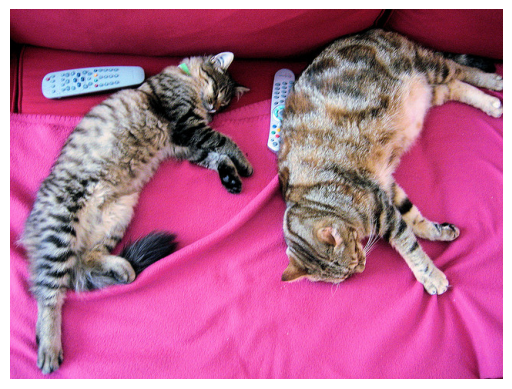

['<start_of_turn>user\n<|image>']


In [5]:
image_url = "http://images.cocodataset.org/val2017/000000039769.jpg"
response = requests.get(image_url)
image = Image.open(BytesIO(response.content)).convert("RGB")

plt.imshow(image)
plt.axis('off')
plt.show()

# Pass image as numpy array WITHOUT manual scaling!
image_np = np.array(image)

# Set max_images_per_prompt to 1 for image test
model.preprocessor.max_images_per_prompt = 1

prompt = "<start_of_turn>user\n\n<|image|>\nWhat is in this image?<end_of_turn>\n<start_of_turn>model\n"

print("Preprocessing...")
# sequence_length is automatically picked from model files (2500)!
preprocessed = model.preprocessor.generate_preprocess(
    {"prompts": [prompt], "images": [image_np]},
)

# Extract stop token IDs
stop_ids = [
    model.preprocessor.tokenizer.end_token_id,
    model.preprocessor.tokenizer.token_to_id("<turn|>"),
]

# Detach preprocessor
original_preprocessor = model.preprocessor
model.preprocessor = None

print("Generating...")
output = model.generate(
    preprocessed,
    max_length=200,
    stop_token_ids=stop_ids,
)

# Restore preprocessor
model.preprocessor = original_preprocessor

print("Decoding...")
decoded = model.preprocessor.tokenizer.detokenize(output)
print("Decoded Output:")
print(decoded)


## 4. Video + Text Inference (Generated Dummy Video)

We will generate a dummy video (random noise) to test the video processing pipeline.


In [6]:
# Generate a dummy video: 1 batch, 8 frames of random noise, size 224x224
dummy_video = np.random.randint(0, 255, (1, 8, 224, 224, 3), dtype=np.uint8)

# Pass video WITHOUT manual scaling!
dummy_video_np = dummy_video[0]

# Set max_images_per_prompt to 8 for this video test (8 frames)
model.preprocessor.max_images_per_prompt = 8

prompt = "<|turn>user\n<|video|>Describe this video.<turn|>\n<|turn>model\n"

print("Preprocessing...")
# sequence_length is automatically picked from model files (2500)!
preprocessed = model.preprocessor.generate_preprocess(
    {"prompts": [prompt], "videos": [dummy_video_np]},
)

# Extract stop token IDs
stop_ids = [
    model.preprocessor.tokenizer.end_token_id,
    model.preprocessor.tokenizer.token_to_id("<turn|>"),
]

# Detach preprocessor
original_preprocessor = model.preprocessor
model.preprocessor = None

print("Generating...")
output = model.generate(
    preprocessed,
    max_length=200,
    stop_token_ids=stop_ids,
)

# Restore preprocessor
model.preprocessor = original_preprocessor

print("Decoding...")
decoded = model.preprocessor.tokenizer.detokenize(output)
print("Decoded Output:")
print(decoded)


['<|turn>user\n<|video><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|vid

## 5. Video + Text Inference (From URL)

We will download a sample video from test-videos.co.uk and run inference.


In [7]:
# Download a sample video (Big Buck Bunny)
video_url = "https://download.blender.org/peach/bigbuckbunny_movies/BigBuckBunny_320x180.mp4"
video_path = "big_buck_bunny.mp4"

if not os.path.exists(video_path):
    print("Downloading video...")
    response = requests.get(video_url)
    with open(video_path, "wb") as f:
        f.write(response.content)
    print("Downloaded!")

# Read video frames using torchvision
import torchvision
vframes, aframes, info = torchvision.io.read_video(video_path, pts_unit="sec")
print(f"Original video shape: {vframes.shape}") # (T, H, W, C)

# Sample 32 frames uniformly
total_frames = vframes.shape[0]
num_frames = 32
indices = np.linspace(0, total_frames - 1, num_frames, dtype=np.int32)
sampled_frames = vframes[indices]
print(f"Sampled video shape: {sampled_frames.shape}") # (32, H, W, C)

# Convert to numpy array
vframes_np = sampled_frames.numpy()

# Set max_images_per_prompt to 32 for video test
model.preprocessor.max_images_per_prompt = 32

prompt = "<|turn>user\n<|video|>Describe this video.<turn|>\n<|turn>model\n"

print("Preprocessing...")
# Pass video WITHOUT manual scaling!
# sequence_length is automatically picked from model files (2500)!
preprocessed = model.preprocessor.generate_preprocess(
    {"prompts": [prompt], "videos": [vframes_np]},
)

# Extract stop token IDs
stop_ids = [
    model.preprocessor.tokenizer.end_token_id,
    model.preprocessor.tokenizer.token_to_id("<turn|>"),
]

# Detach preprocessor
original_preprocessor = model.preprocessor
model.preprocessor = None

print("Generating...")
output = model.generate(
    preprocessed,
    max_length=200,
    stop_token_ids=stop_ids,
)

# Restore preprocessor
model.preprocessor = original_preprocessor

print("Decoding...")
decoded = model.preprocessor.tokenizer.detokenize(output)
print("Decoded Output:")
print(decoded)


Video shape: (300, 1080, 1920, 3)


['<|turn>user\n<|video><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|video|><|vid

## 6. Code Generation Example


In [8]:
prompt = "<start_of_turn>user\nWrite a Python function to check if a string is a palindrome.<end_of_turn>\n<start_of_turn>model\n"
response = model.generate(prompt, max_length=300)
print(response)


<start_of_turn>user
Write a Python function to check if a string is a palindrome.<end_of_turn>
<start_of_turn>model
```python
def is_palindrome(s):
  """
  Checks if a given string is a palindrome.

  A palindrome is a sequence that reads the same backward as forward.
  This function ignores case and non-alphanumeric characters.

  Args:
    s: The input string.

  Returns:
    True if the string is a palindrome, False otherwise.
  """
  # 1. Preprocess the string: convert to lowercase and remove non-alphanumeric characters
  processed_s = "".join(char.lower() for char in s if char.isalnum())

  # 2. Check if the processed string is equal to its reverse
  return processed_s == processed_s[::-1]

# Example Usage:
print(f"'A man, a plan, a canal: Panama' is a palindrome: {is_palindrome('A man, a plan, a canal: Panama')}")
print(f"'racecar' is a palindrome: {is_palindrome('racecar')}")
print(f"'hello' is a palindrome: {is_palindrome('hello')}")
print(f"'Madam' is a palindrome: {is_palindr

## 7. Function Calling (Tool Use) Example

We will provide the model with a tool definition and ask it to use it.


In [9]:
prompt = """<start_of_turn>user
You have access to the following tools:
[
  {
    "name": "get_current_weather",
    "description": "Get the current weather in a given location",
    "parameters": {
      "type": "object",
      "properties": {
        "location": {
          "type": "string",
          "description": "The city and state, e.g. San Francisco, CA"
        }
      },
      "required": ["location"]
    }
  }
]

What's the weather like in Tokyo?<end_of_turn>
<start_of_turn>model
"""

response = model.generate(prompt, max_length=200)
print(response)


<start_of_turn>user
You have access to the following tools:
[
  {
    "name": "get_current_weather",
    "description": "Get the current weather in a given location",
    "parameters": {
      "type": "object",
      "properties": {
        "location": {
          "type": "string",
          "description": "The city and state, e.g. San Francisco, CA"
        }
      },
      "required": ["location"]
    }
  }
]

What's the weather like in Tokyo?<end_of_turn>
<start_of_turn>model
print(get_current_weather(location="Tokyo"))
<end_of_turn><turn|>
